**Assignment - Part 1**

Assuming an NxN symmetric matrix with diagonal and super-diagonal and sample values which represents the Hamiltonian of the system.

Diagonal elements = -5

Super Diagonal elements = -1

We plot the the distribution of eigenvalues using a histogram plot.

This relates to the case of N-atoms of Hydrogren in proximity.

The diagonal elements of the matrix represent the energy of the electrons and super-diagonal elements represents the interaction between the first nearest neighbours.

We ignore the interactions of second nearest neighbours and so on to obtain zero entry in the matrix. 

We find the eigenvalue of the Hamiltonian matrix to obtain the energy levels of the system. We analyse how this energy level distribution changes with number of atoms. 

N = 10, 20, 50, 100

Also, we then impose periodic boundary conditions, considering the interaction between the first and the last atom, so the (1,N) and (N,1) entry is also -1. Then we analyse how the distribution is changed.

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
N = 10
#Create a nxn matrix with all diagonal values equal to -5 and super diagonal values equal to -1
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N - 1), k=-1) + np.diag(-1 * np.ones(N - 1), k=1)
print("Hamiltonian Matrix H:")
print(H)

Hamiltonian Matrix H:
[[-5. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1. -5. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1. -5. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1. -5. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1. -5. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1. -5. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1. -5. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1. -5. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1. -5. -1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. -1. -5.]]


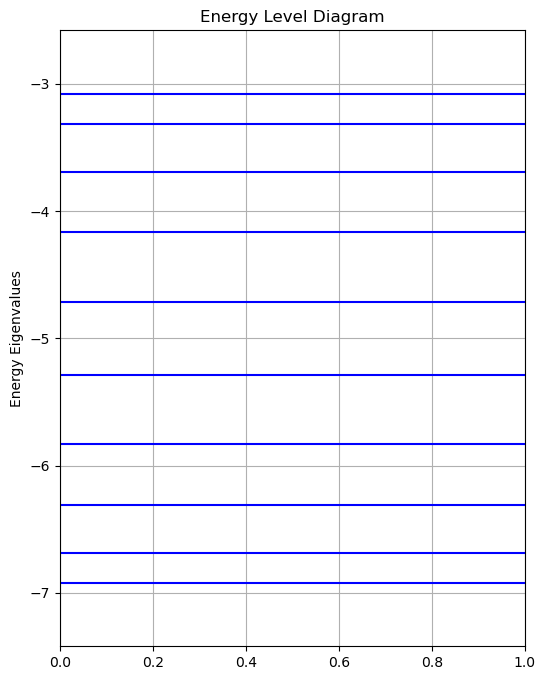

In [90]:
#Finding eigenvalues of H
eigval, eigvec = np.linalg.eigh(H)

def plot_eigval(eigval): #Energy level diagram
    plt.figure(figsize=(6, 8))
    for i in range(len(eigval)):
        plt.hlines(eigval[i], 0, 1, colors='b')
    plt.title('Energy Level Diagram')
    plt.ylabel('Energy Eigenvalues')
    plt.xlim(0, 1)
    plt.ylim(min(eigval) - 0.5, max(eigval) + 0.5)
    plt.grid()
    plt.show()

plot_eigval(eigval)
    

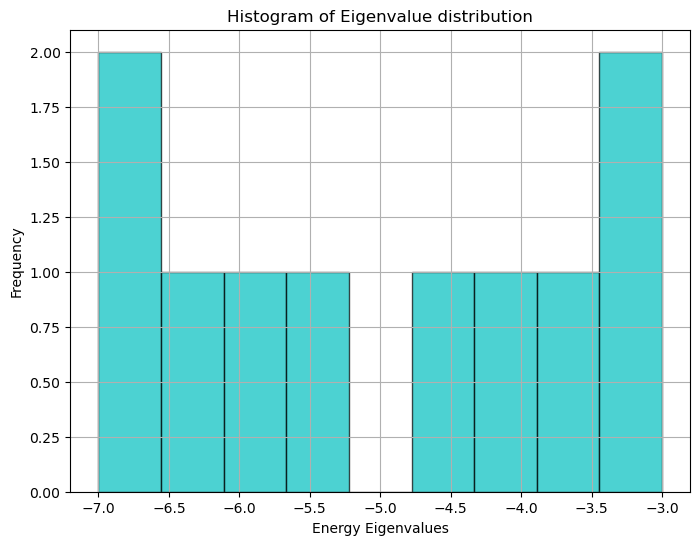

In [91]:
def histogram_eigval(eigval, div, range = (-7,-3)): #Histogram of eigenvalues #The bins can be adjusted based on the range and distribution of eigenvalues manually, also the range can be specified
    plt.figure(figsize=(8, 6))
    toprange = range[1]
    bottomrange = range[0]
    bins = np.linspace(bottomrange, toprange, div)
    plt.hist(eigval, bins=bins, color='c', edgecolor='k', alpha=0.7)
    plt.title('Histogram of Eigenvalue distribution')
    plt.xlabel('Energy Eigenvalues')
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()

histogram_eigval(eigval,10)

For N = 20

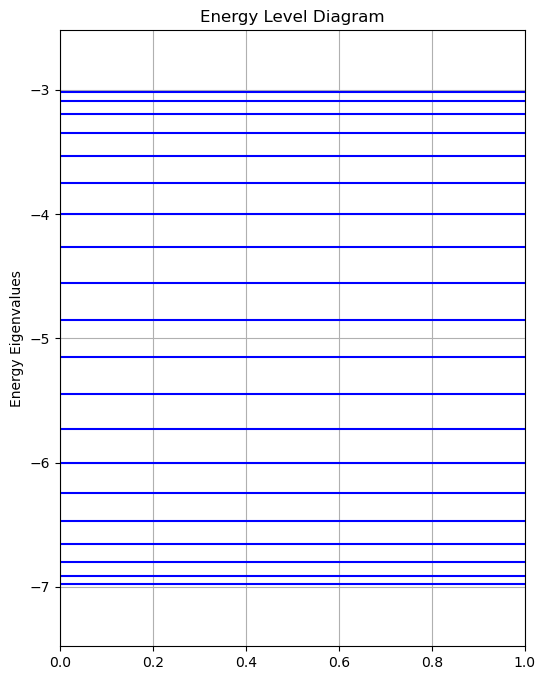

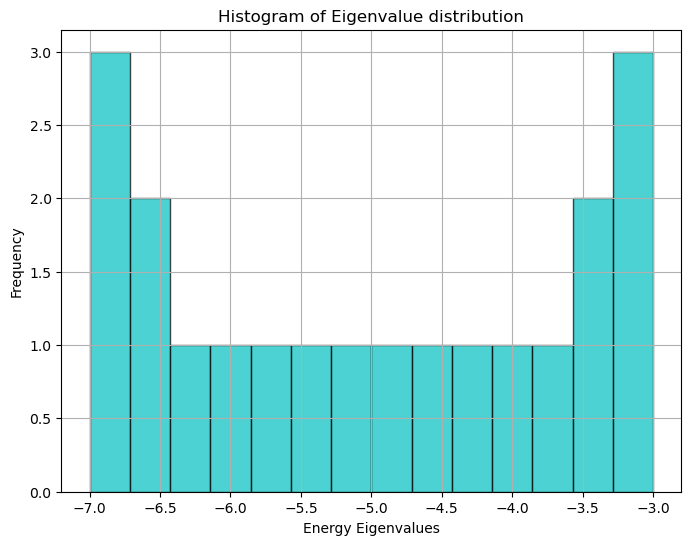

In [92]:
N = 20
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N - 1), k=-1) + np.diag(-1 * np.ones(N - 1), k=1)
eigval, eigvec = np.linalg.eigh(H)
plot_eigval(eigval)
histogram_eigval(eigval,15)

For N = 100

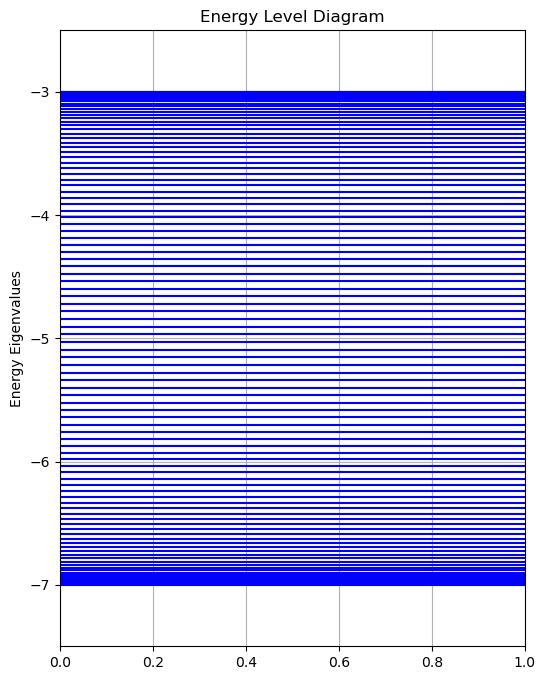

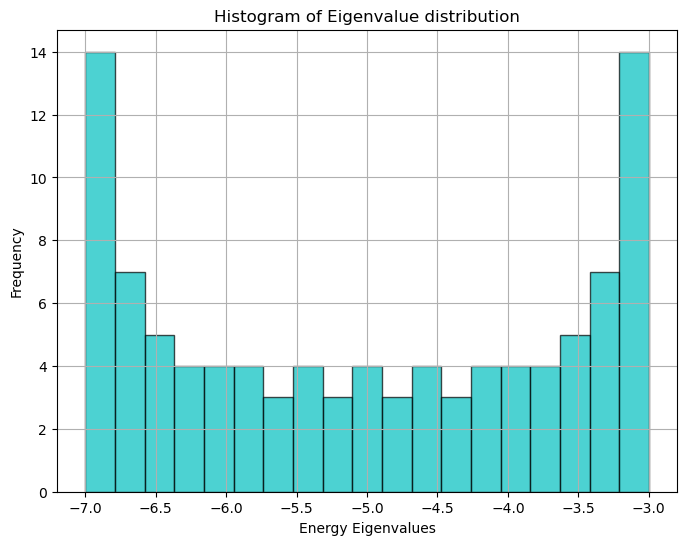

In [93]:
N = 100
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N - 1), k=-1) + np.diag(-1 * np.ones(N - 1), k=1)
eigval, eigvec = np.linalg.eigh(H)
plot_eigval(eigval)
histogram_eigval(eigval,20)

Now we impose periodic Boundary condition in N=100 case.


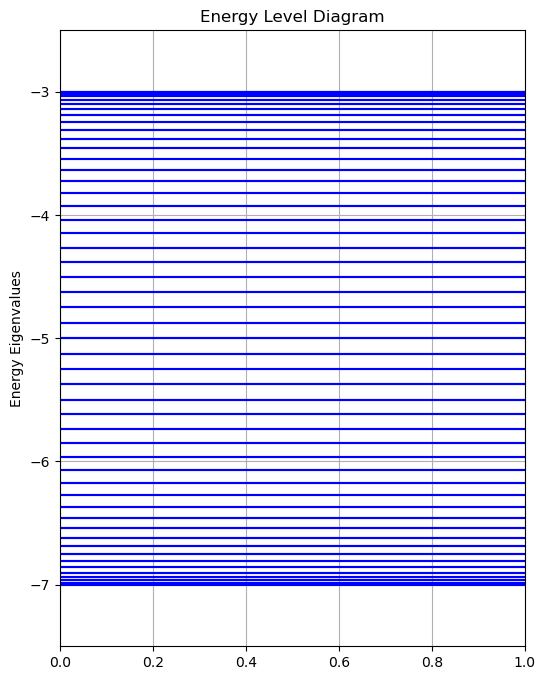

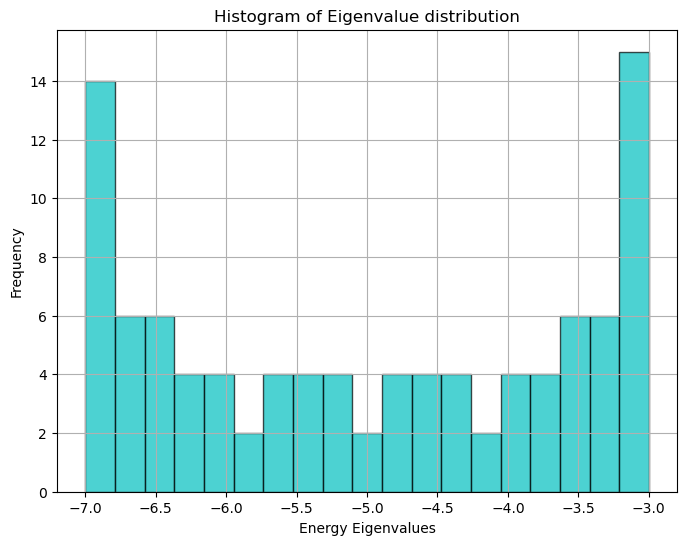

In [94]:
#Add a (1, N) and (N, 1) element to H to make it periodic
H[0, N - 1] = -1
H[N - 1, 0] = -1
eigval, eigvec = np.linalg.eigh(H)
plot_eigval(eigval)
histogram_eigval(eigval,20)

Trying for N = 1000 to see the nature of the energy distribution plot properly

Energy distribution becomes a **band**

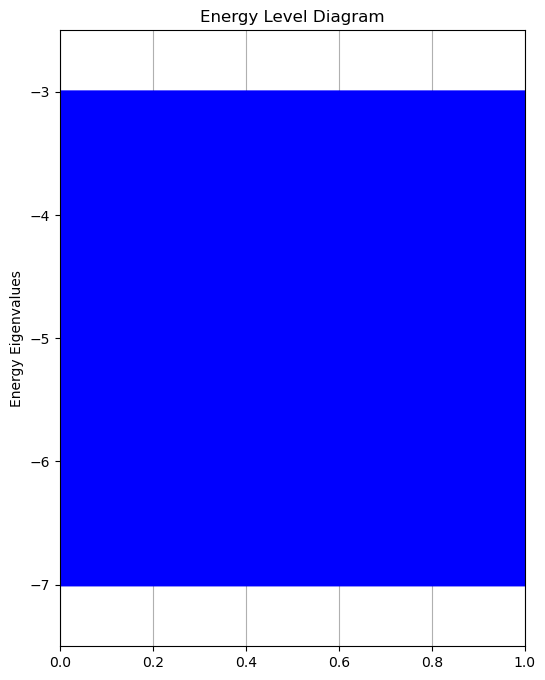

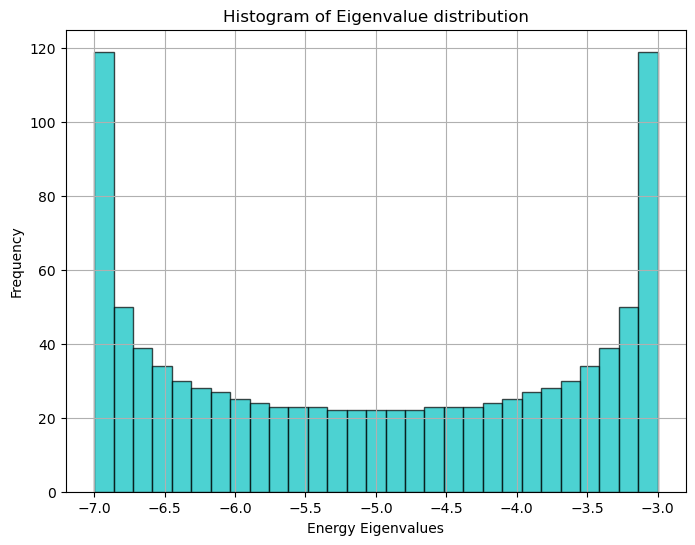

In [95]:
N = 1000
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N - 1), k=-1) + np.diag(-1 * np.ones(N - 1), k=1)
eigval, eigvec = np.linalg.eigh(H)
plot_eigval(eigval)
histogram_eigval(eigval,30)


Hence we analysed the energy distribution of the system considering nearest neighbour interactions for N Hydrogen atoms in proximity. 

**Assignment Part 2 - Block Diagonal Matrix**

We consider an 8x8 matrix with 2 4x4 diagonal blocks. These blocks are similar to matrices considered above. They have a diagonal and a super-diagonal and are symmetric blocks. 

1st Block:

Diagonal entries = -2
Super-diagonal entries = -0.5

2nd Block:

Diagonal entries = -5
Super-diagonal entries = -1

We find the eigenvalues of the overall matrix and analyse the distribution through a histogram plot. 

Then we add some extra terms on the off-diagonal blocks (diagonal elements of the off-diagonal blocks, entry = -0.5). Then perform the same analysis.

In [96]:
#8x8 matrix with two 4x4 diagonal blocks
H = np.diag(-5*np.ones(8)) + np.diag(-1 * np.ones(7), k=-1) + np.diag(-1 * np.ones(7), k=1)
H[0:4, 0:4] = np.diag(-2*np.ones(4)) + np.diag(-0.5 * np.ones(3), k=-1) + np.diag(-0.5 * np.ones(3), k=1)
H[4:8, 4:8] = np.diag(-5*np.ones(4)) + np.diag(-1 * np.ones(3), k=-1) + np.diag(-1 * np.ones(3), k=1)
H[3,4] = 0
H[4,3] = 0
H

array([[-2. , -0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [-0.5, -2. , -0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. , -0.5, -2. , -0.5,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. , -0.5, -2. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. , -5. , -1. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. , -1. , -5. , -1. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. , -1. , -5. , -1. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. , -1. , -5. ]])

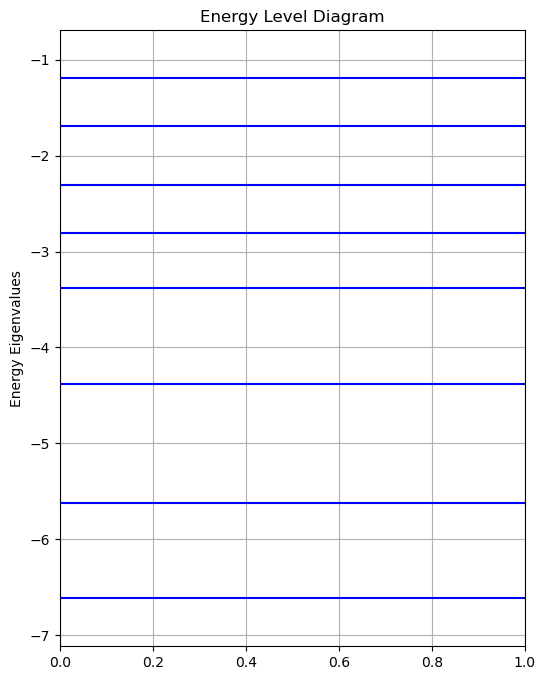

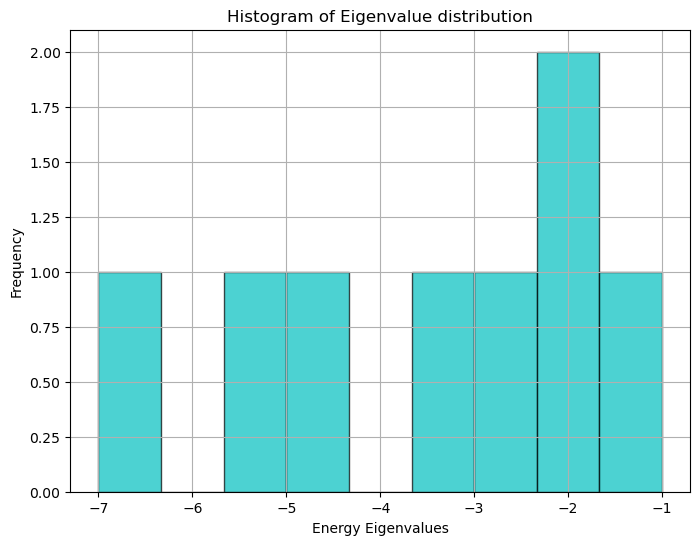

In [97]:
eigval, eigvec = np.linalg.eigh(H)
plot_eigval(eigval)
histogram_eigval(eigval,10, range=(-7,-1))

In [98]:
#Lets scale it up 100 times
N = 1000
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N-1), k=-1) + np.diag(-1 * np.ones(N-1), k=1)
H[0:int(N/2), 0:int(N/2)] = np.diag(-2*np.ones(int(N/2))) + np.diag(-0.5 * np.ones((int(N/2)) - 1), k=-1) + np.diag(-0.5 * np.ones((int(N/2)) - 1), k=1)
H[int(N/2):N, int(N/2):N] = np.diag(-5*np.ones(int(N/2))) + np.diag(-1 * np.ones((int(N/2)) - 1), k=-1) + np.diag(-1 * np.ones((int(N/2)) - 1), k=1)
H[(int(N/2))-1,int(N/2)] = 0
H[int(N/2),(int(N/2))-1] = 0
H

array([[-2. , -0.5,  0. , ...,  0. ,  0. ,  0. ],
       [-0.5, -2. , -0.5, ...,  0. ,  0. ,  0. ],
       [ 0. , -0.5, -2. , ...,  0. ,  0. ,  0. ],
       ...,
       [ 0. ,  0. ,  0. , ..., -5. , -1. ,  0. ],
       [ 0. ,  0. ,  0. , ..., -1. , -5. , -1. ],
       [ 0. ,  0. ,  0. , ...,  0. , -1. , -5. ]], shape=(1000, 1000))

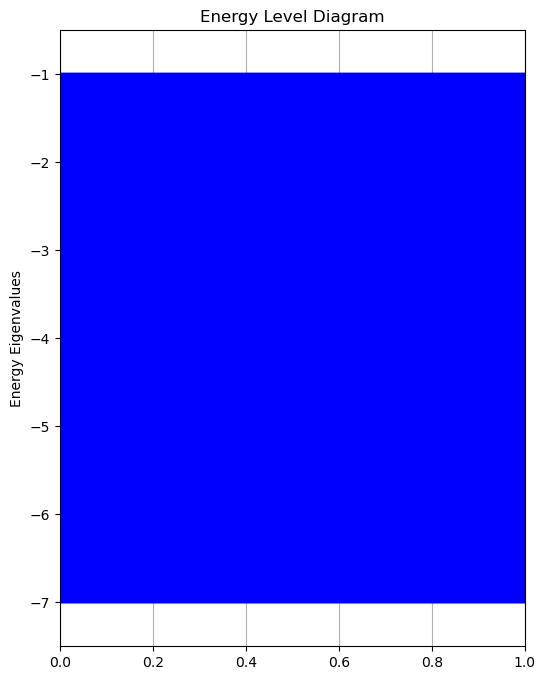

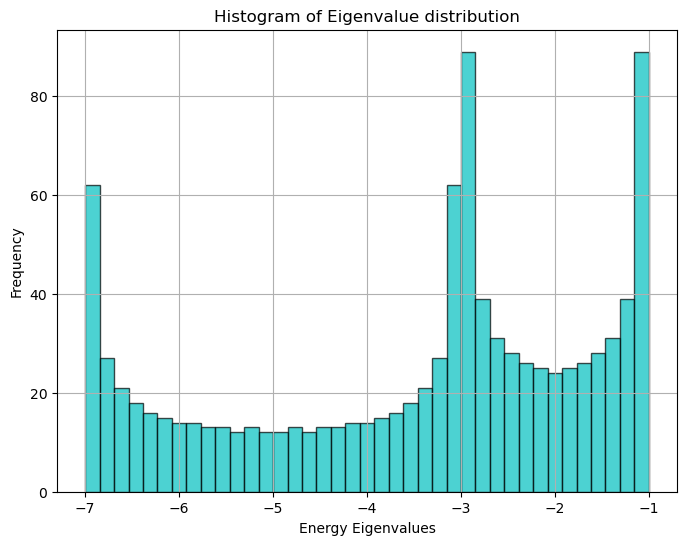

In [99]:
eigval, eigvec = np.linalg.eigh(H)
plot_eigval(eigval)
histogram_eigval(eigval,40, range=(-7, -1))

Using off-diagonal blocks noise = -0.7 to get a more noticeable energy gap in the energy levels. 

[[-2.  -0.5  0.  ...  0.   0.   0. ]
 [-0.5 -2.  -0.5 ...  0.   0.   0. ]
 [ 0.  -0.5 -2.  ...  0.   0.   0. ]
 ...
 [ 0.   0.   0.  ... -5.  -1.   0. ]
 [ 0.   0.   0.  ... -1.  -5.  -1. ]
 [ 0.   0.   0.  ...  0.  -1.  -5. ]]


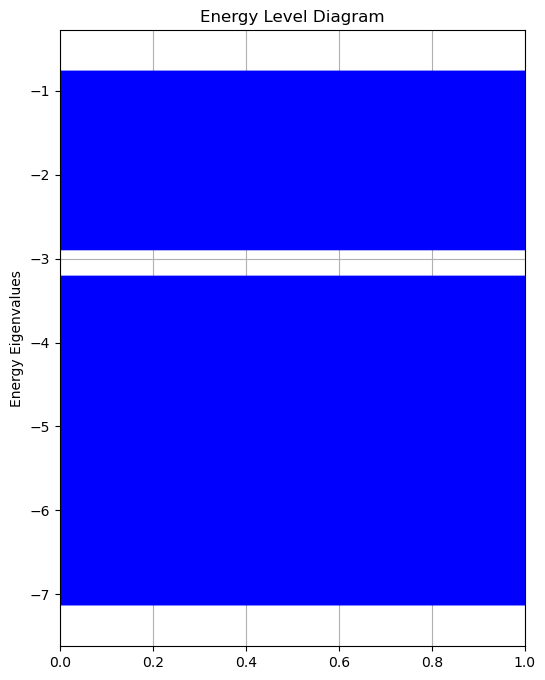

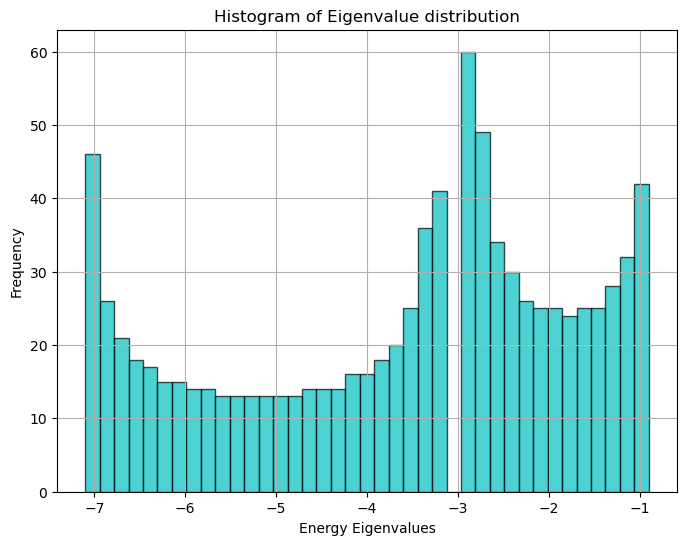

In [100]:
#Adding diagonal terms to the off diagonal blocks to create some disorder
H[0:int(N/2), int(N/2):N] += np.diag(np.ones(int(N/2)) * -0.7)
H[int(N/2):N, 0:int(N/2)] += np.diag(np.ones(int(N/2)) * -0.7)
print(H)
eigval, eigvec = np.linalg.eigh(H)
plot_eigval(eigval)
histogram_eigval(eigval,40, range=(-7.1, -0.9))

**Assignment - Part 3**

**Dimerization**

We consider a situation of 1D chain of two Hydrogen atoms alternating and forming a dimer. This modifies the Hamiltonian Matrix to the following form. 

Its the same Hamiltonian matrix as for the first case of 1D chain of H-atoms but here, the interactions terms will alternate between a large and a small value.

Higher interaction term indicates H2 atom bond

Smaller interaction term indicates the dimer bond (due to weak van-der waal forces)



In [101]:
N = 10
#Create a nxn matrix with all diagonal values equal to -5 and super diagonal values alternating between -1.5 and -0.5.
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N - 1), k=-1) + np.diag(-1 * np.ones(N - 1), k=1)
for i in range(N - 1):
    if i % 2 == 0:
        H[i, i + 1] = -1.5
        H[i + 1, i] = -1.5
    else:
        H[i, i + 1] = -0.5
        H[i + 1, i] = -0.5
print("Hamiltonian Matrix H:")
print(H)

Hamiltonian Matrix H:
[[-5.  -1.5  0.   0.   0.   0.   0.   0.   0.   0. ]
 [-1.5 -5.  -0.5  0.   0.   0.   0.   0.   0.   0. ]
 [ 0.  -0.5 -5.  -1.5  0.   0.   0.   0.   0.   0. ]
 [ 0.   0.  -1.5 -5.  -0.5  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -0.5 -5.  -1.5  0.   0.   0.   0. ]
 [ 0.   0.   0.   0.  -1.5 -5.  -0.5  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.  -0.5 -5.  -1.5  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -1.5 -5.  -0.5  0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -0.5 -5.  -1.5]
 [ 0.   0.   0.   0.   0.   0.   0.   0.  -1.5 -5. ]]


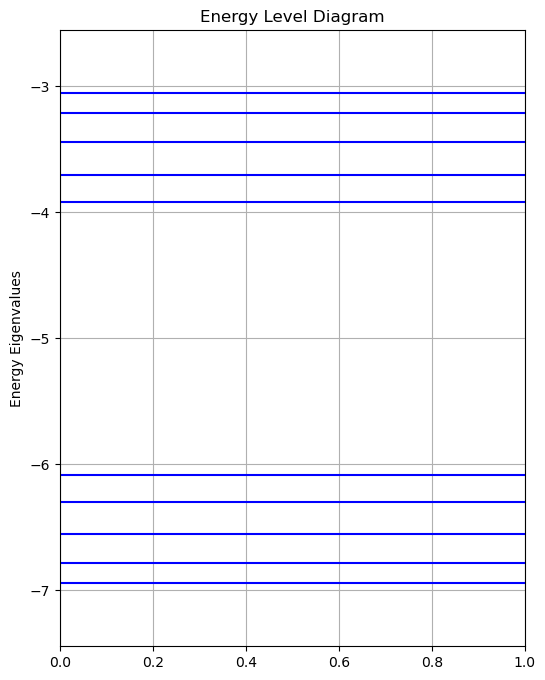

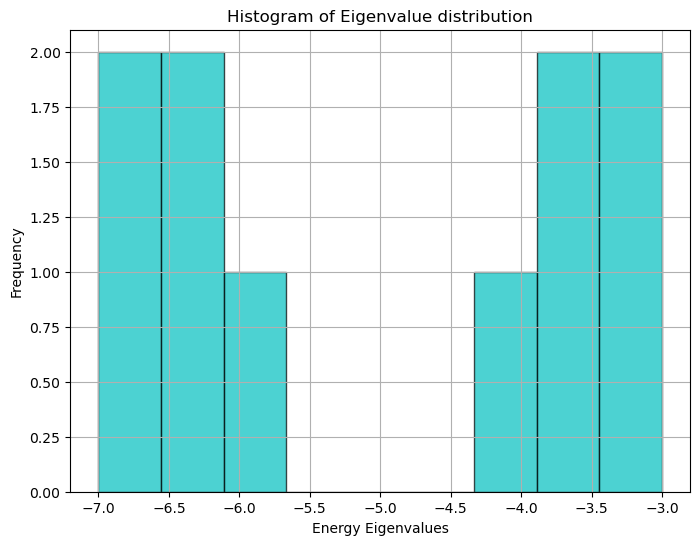

In [102]:
eigval, eigvec = np.linalg.eigh(H)
plot_eigval(eigval)
histogram_eigval(eigval,10, range=(-7, -3))

We repeat the same thing for N=1000 to see the effect properly

Hamiltonian Matrix H:
[[-5.  -1.5  0.  ...  0.   0.   0. ]
 [-1.5 -5.  -0.5 ...  0.   0.   0. ]
 [ 0.  -0.5 -5.  ...  0.   0.   0. ]
 ...
 [ 0.   0.   0.  ... -5.  -0.5  0. ]
 [ 0.   0.   0.  ... -0.5 -5.  -1.5]
 [ 0.   0.   0.  ...  0.  -1.5 -5. ]]


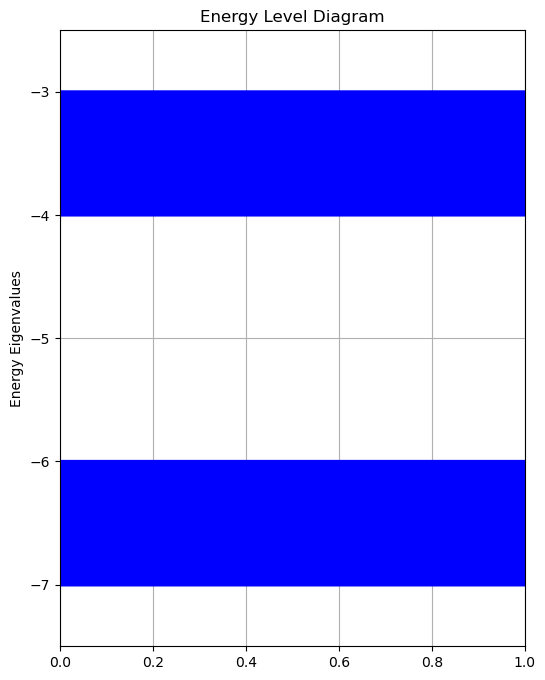

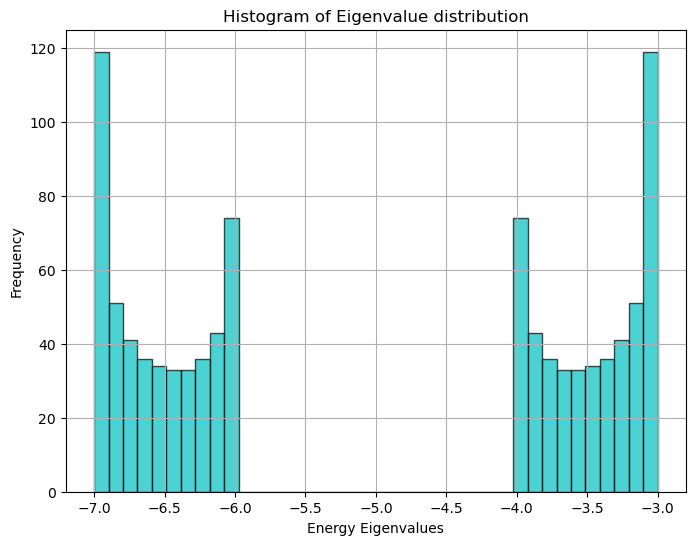

In [103]:
N = 1000
#Create a nxn matrix with all diagonal values equal to -5 and super diagonal values alternating between -1.5 and -0.5.
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N - 1), k=-1) + np.diag(-1 * np.ones(N - 1), k=1)
for i in range(N - 1):
    if i % 2 == 0:
        H[i, i + 1] = -1.5
        H[i + 1, i] = -1.5
    else:
        H[i, i + 1] = -0.5
        H[i + 1, i] = -0.5
print("Hamiltonian Matrix H:")
print(H)

eigval, eigvec = np.linalg.eigh(H)
plot_eigval(eigval)
histogram_eigval(eigval,40, range=(-7, -3))

**Assignment - Part 4**

We consider a 1D chain of N atoms. Taking E0 = -5eV and beta = -0.5eV. 
For N=5, 10, 20 50 and 100, we plot the energy distribution histogram i.e. density of states vs energy. Also, we mark the Fermi energy level assuming a spin degeneracy of 2 (electron is spin-1/2). 

Also this part: for N=50
Plot (x axis : 1,2,3,... are site of atoms in some arbitrary spacing, y axis : value of the eigen state at each site)  
the minimum, maximum and the highest occupied and lowest unoccupied energy eigenstates.


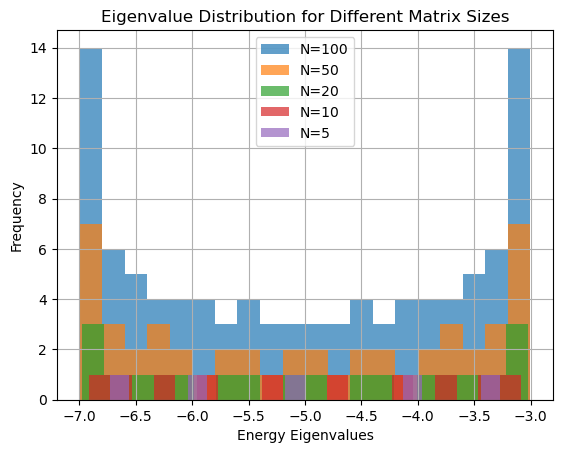

In [104]:
N = [100, 50, 20, 10 ,5]
plt.figure()
for n in N:
    H = np.diag(-5*np.ones(n)) + np.diag(-1 * np.ones(n - 1), k=-1) + np.diag(-1 * np.ones(n - 1), k=1)
    eigval, eigvec = np.linalg.eigh(H)
    plt.hist(eigval, bins=20, alpha=0.7, label=f'N={n}')
    
plt.title('Eigenvalue Distribution for Different Matrix Sizes')
plt.xlabel('Energy Eigenvalues')
plt.grid()
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [105]:
def Plot_eigenstates_and_energy_levels(N, eigvals, eigvecs, bin_width=0.2, label=""):
    sites = np.arange(1, N + 1)
    bins = np.arange(eigvals.min(), eigvals.max() + bin_width, bin_width)
    plt.figure(figsize=(10, 6))
    plt.hist(eigval, bins=bins, color='c', edgecolor='k', alpha=0.7)
    Ef = eigvals[int(np.ceil(N/2))-1 ]
    plt.axvline(Ef, linestyle='--', label='Fermi level', color='r')
    plt.title('Histogram of Eigenvalue distribution')
    plt.xlabel('Energy Eigenvalues')
    plt.ylabel('Density of States')
    plt.grid()
    plt.show()

    #Energy level diagram
    plt.figure(figsize=(6, 8))
    for i in range(len(eigval)):
        plt.hlines(eigval[i], 0, 1, colors='b')
    plt.title('Energy Level Diagram')
    Ef = eigvals[int(np.ceil(N/2))-1 ]
    plt.axhline(Ef, linestyle='-', label='Fermi level', color='r')
    plt.ylabel('Energy Eigenvalues')
    plt.xlim(0, 1)
    plt.ylim(min(eigval) - 0.5, max(eigval) + 0.5)
    plt.legend()
    plt.grid()
    plt.show()

    #Eigenstates plot
    idx_min  = 0          # lowest energy
    idx_max  = N -1      # highest energy
    idx_homo = int(np.ceil(N/2)) -1   # HOMO
    idx_lumo = idx_homo + 1       # LUMO

    
    plt.figure(figsize=(12,5))
    plt.plot(sites, eigvecs[:, idx_min],  marker='o', label='Lowest energy')
    plt.plot(sites, eigvecs[:, idx_max],  marker='o', label='Highest energy')
    plt.xlabel("Site index")
    plt.ylabel("Eigenstate amplitude")
    plt.title(f"Eigenstates {label}")
    plt.legend()
    plt.tight_layout()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12,5))
    plt.plot(sites, eigvecs[:, idx_homo], marker='o', label='HOMO', color='r')
    plt.plot(sites, eigvecs[:, idx_lumo], marker='o', label='LUMO', color='b')
    plt.xlabel("Site index")
    plt.ylabel("Eigenstate amplitude")
    plt.title(f"Eigenstates {label}")
    plt.legend()
    plt.tight_layout()
    plt.grid()
    plt.show()


Hamiltonian Matrix H:
[[-5. -1.  0.  0.  0.]
 [-1. -5. -1.  0.  0.]
 [ 0. -1. -5. -1.  0.]
 [ 0.  0. -1. -5. -1.]
 [ 0.  0.  0. -1. -5.]]
[-0.28867513 -0.5        -0.57735027 -0.5        -0.28867513]


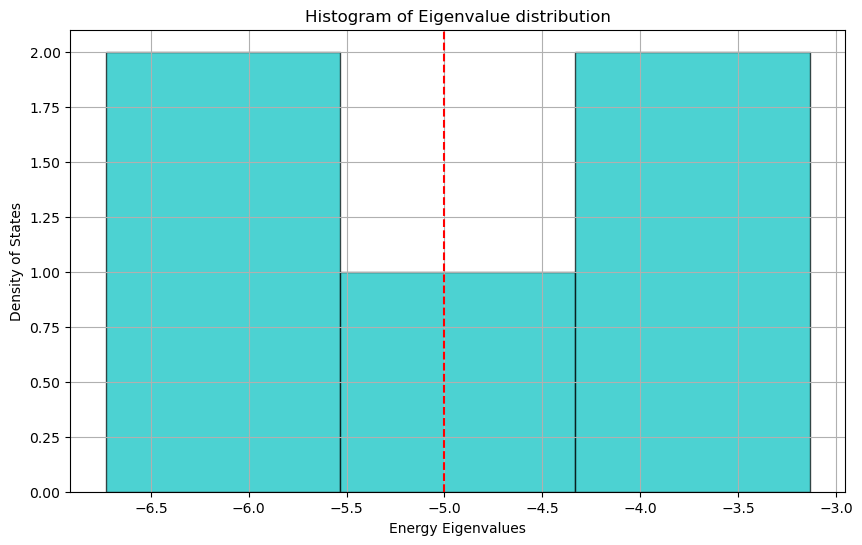

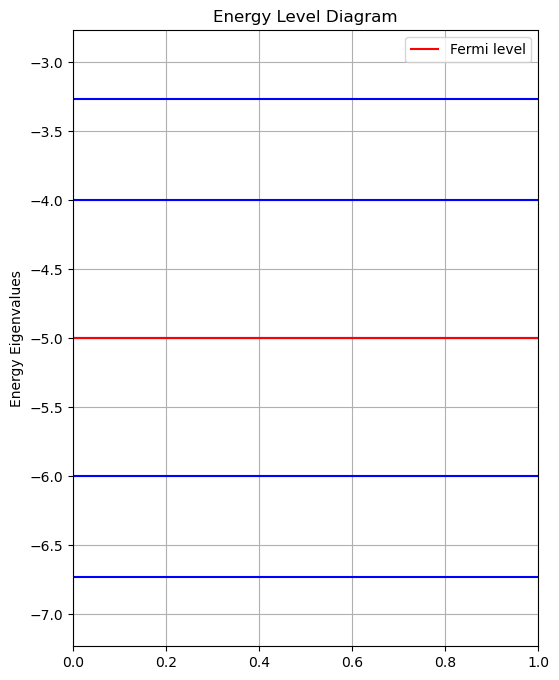

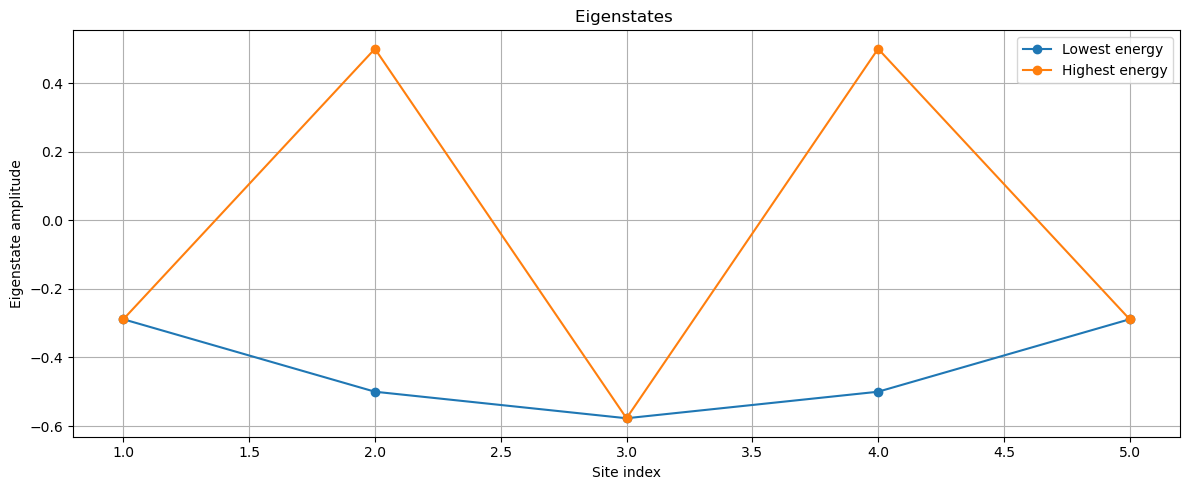

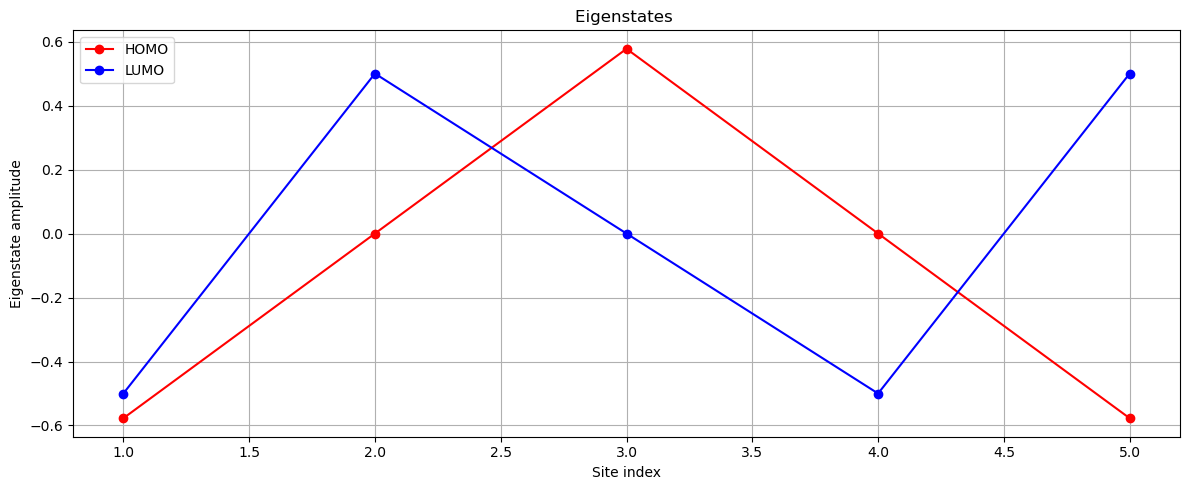

In [106]:
N = 5
#Create a nxn matrix with all diagonal values equal to -5 and super diagonal values equal to -1
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N - 1), k=-1) + np.diag(-1 * np.ones(N - 1), k=1)
print("Hamiltonian Matrix H:")
print(H)
eigval, eigvec = np.linalg.eigh(H)
print(eigvec[:,0])
Plot_eigenstates_and_energy_levels(N,eigval, eigvec, bin_width=1.2)


Hamiltonian Matrix H:
[[-5. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1. -5. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1. -5. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1. -5. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1. -5. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1. -5. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1. -5. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1. -5. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1. -5. -1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. -1. -5.]]


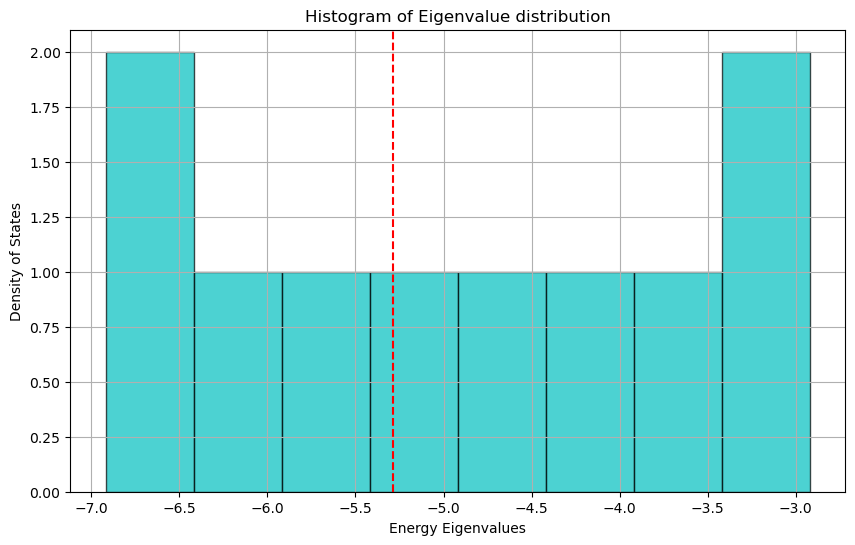

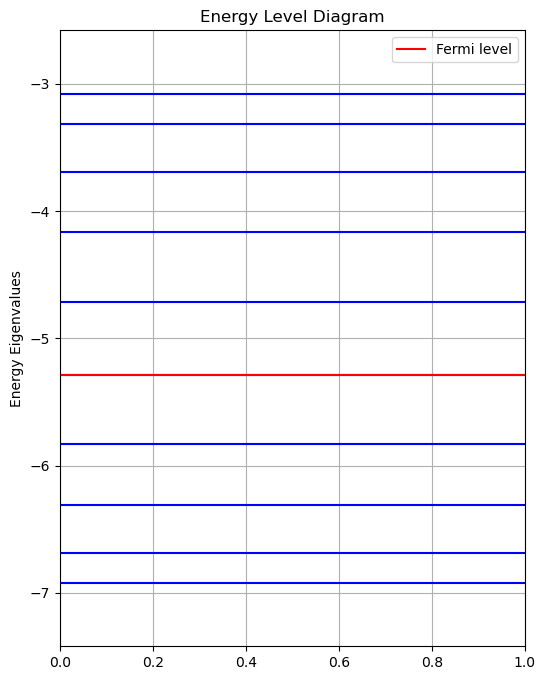

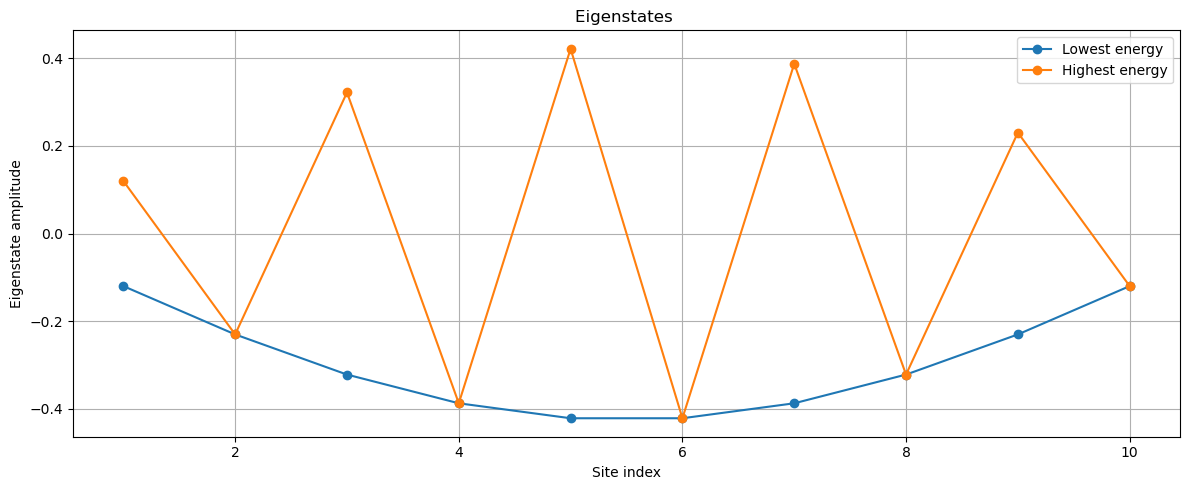

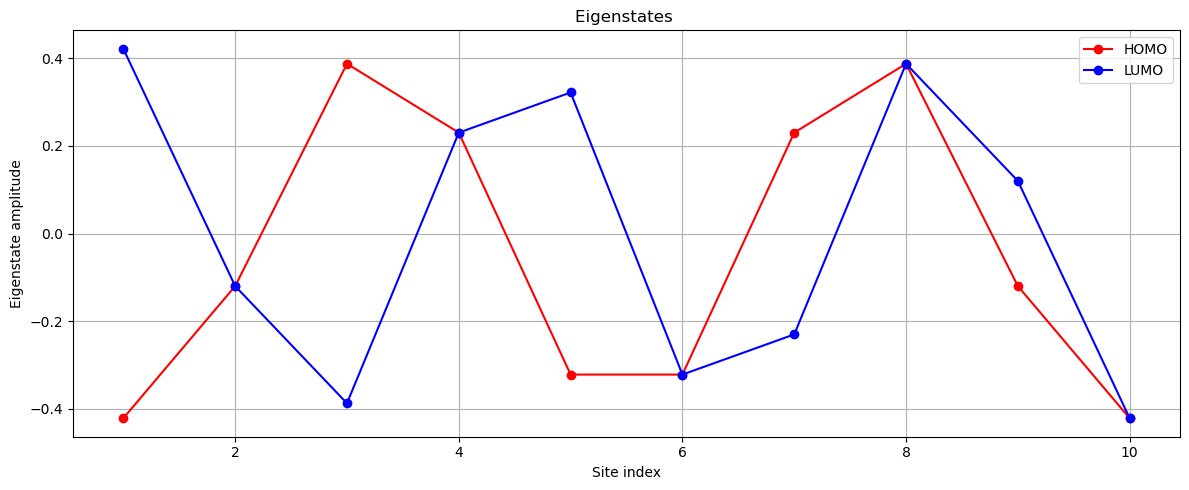

In [107]:
N = 10
#Create a nxn matrix with all diagonal values equal to -5 and super diagonal values equal to -1
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N - 1), k=-1) + np.diag(-1 * np.ones(N - 1), k=1)
print("Hamiltonian Matrix H:")
print(H)

eigval, eigvec = np.linalg.eigh(H)
Plot_eigenstates_and_energy_levels(N,eigval, eigvec, bin_width=0.5)

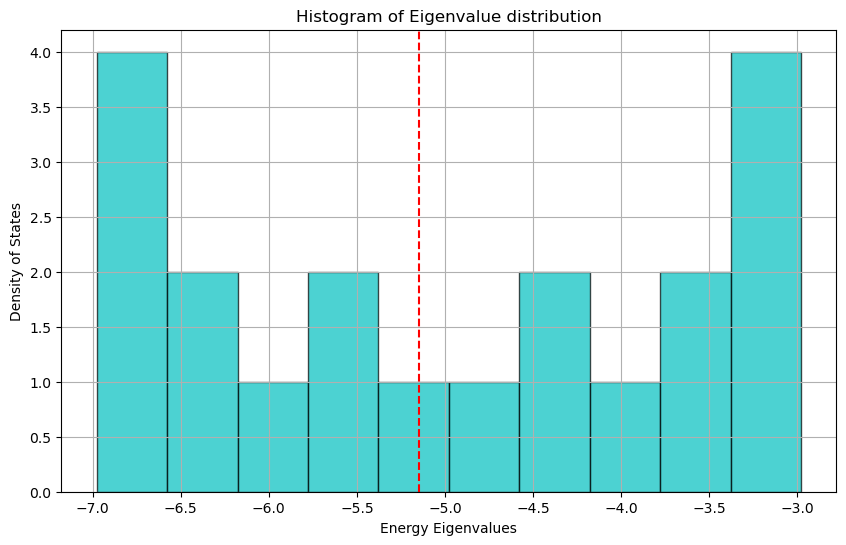

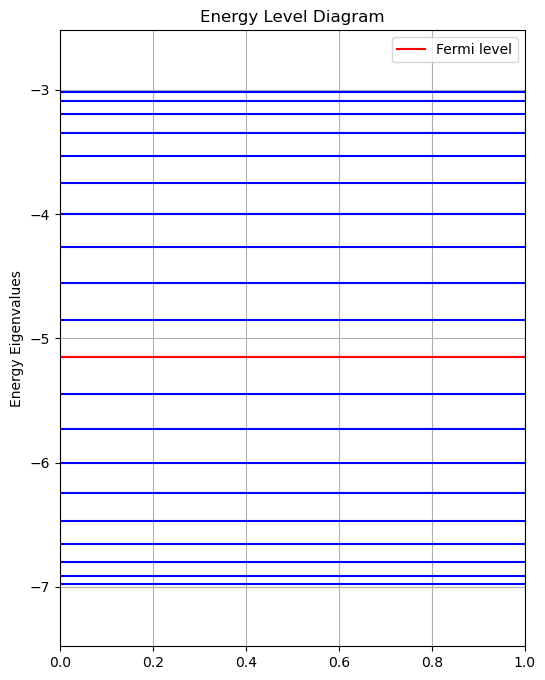

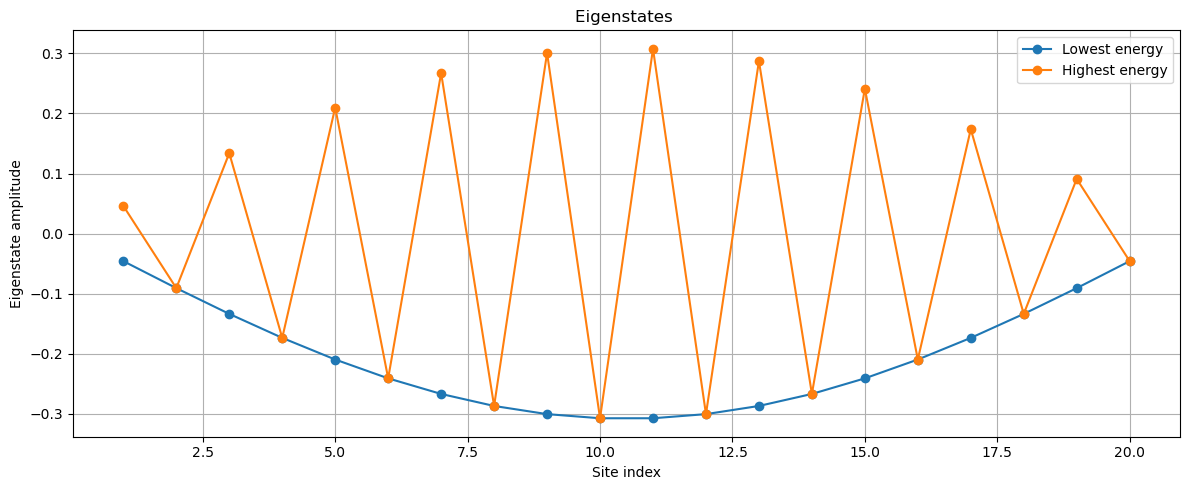

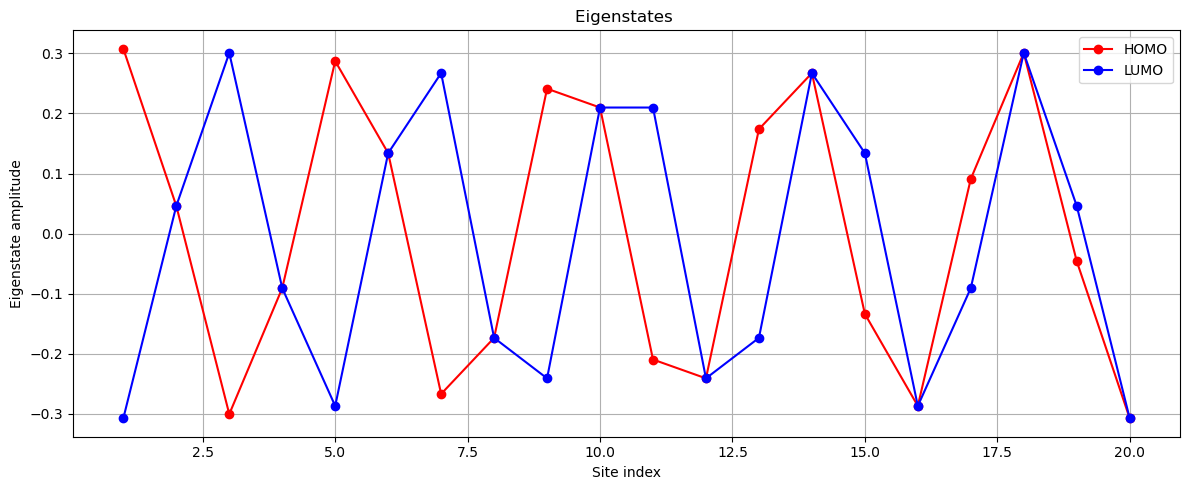

In [108]:
N = 20
#Create a nxn matrix with all diagonal values equal to -5 and super diagonal values equal to -1
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N - 1), k=-1) + np.diag(-1 * np.ones(N - 1), k=1)

eigval, eigvec = np.linalg.eigh(H)
Plot_eigenstates_and_energy_levels(N,eigval, eigvec, bin_width=0.4)

Hamiltonian Matrix H:
[[-5. -1.  0. ...  0.  0.  0.]
 [-1. -5. -1. ...  0.  0.  0.]
 [ 0. -1. -5. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -5. -1.  0.]
 [ 0.  0.  0. ... -1. -5. -1.]
 [ 0.  0.  0. ...  0. -1. -5.]]


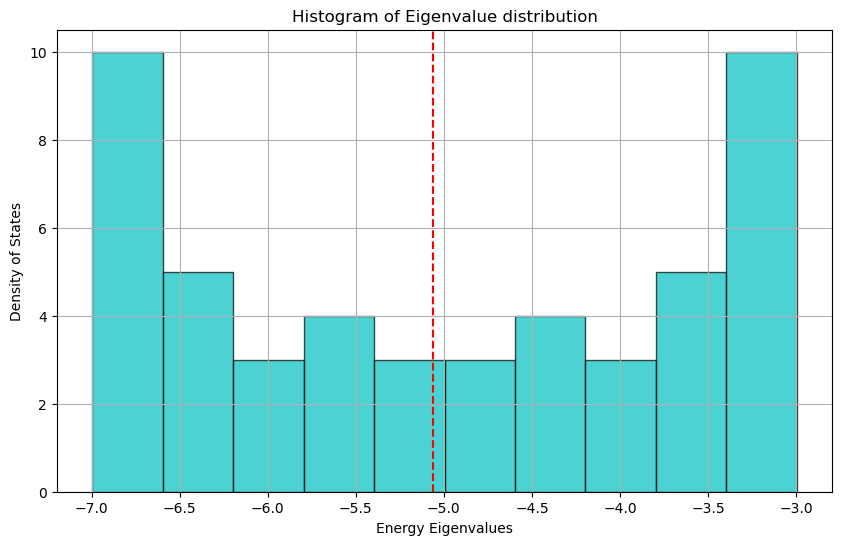

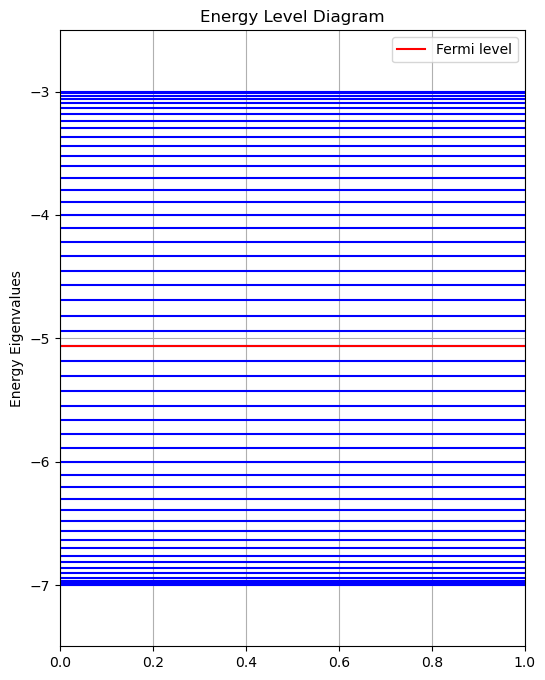

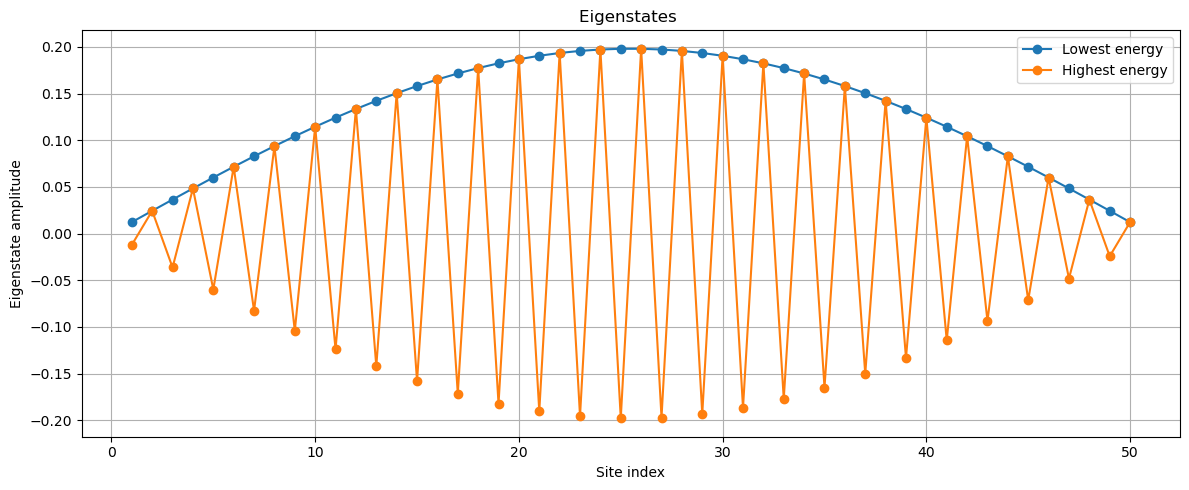

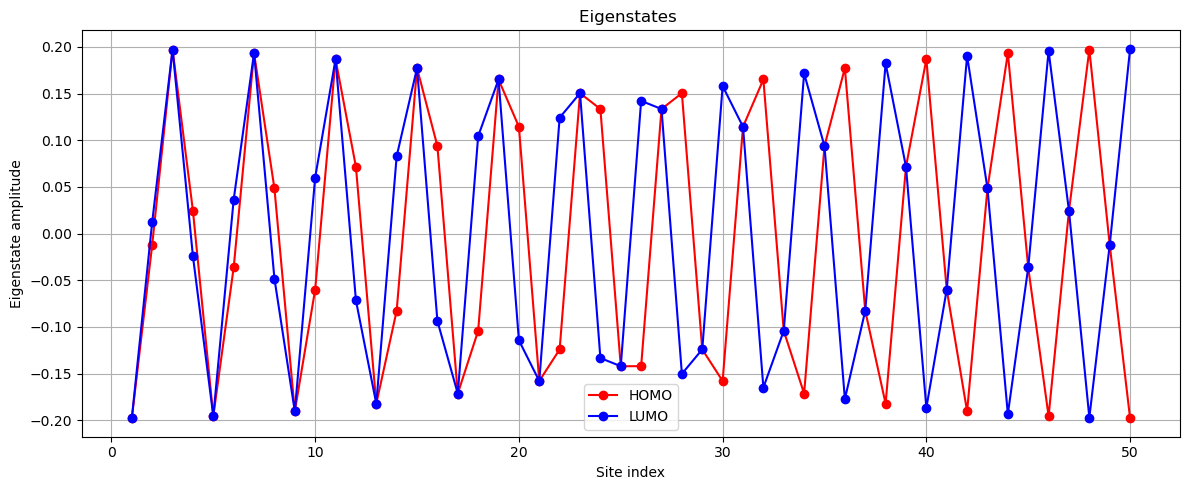

In [109]:
N = 50
#Create a nxn matrix with all diagonal values equal to -5 and super diagonal values equal to -1
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N - 1), k=-1) + np.diag(-1 * np.ones(N - 1), k=1)
print("Hamiltonian Matrix H:")
print(H)

eigval, eigvec = np.linalg.eigh(H)
Plot_eigenstates_and_energy_levels(N,eigval, eigvec, bin_width=0.4)

Hamiltonian Matrix H:
[[-5. -1.  0. ...  0.  0.  0.]
 [-1. -5. -1. ...  0.  0.  0.]
 [ 0. -1. -5. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -5. -1.  0.]
 [ 0.  0.  0. ... -1. -5. -1.]
 [ 0.  0.  0. ...  0. -1. -5.]]


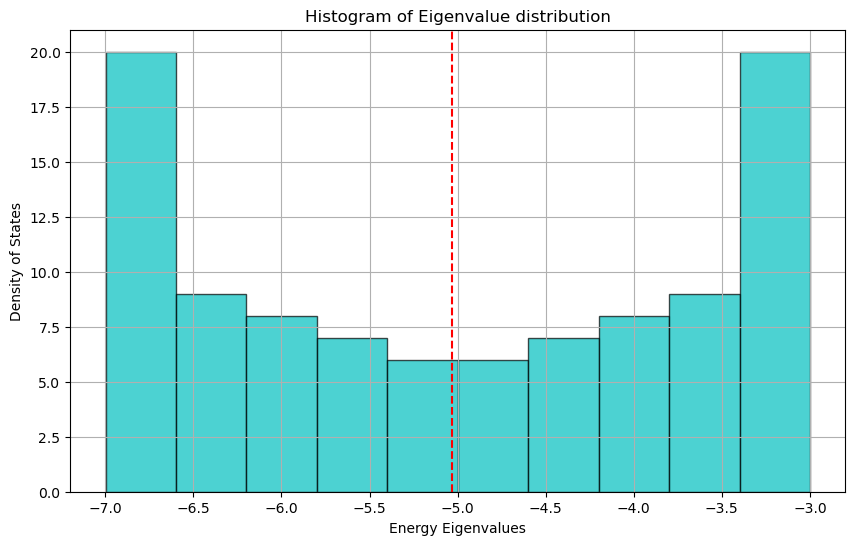

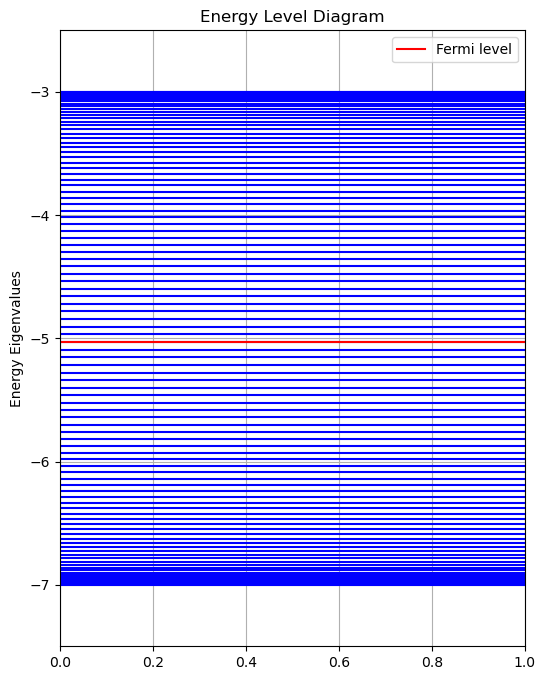

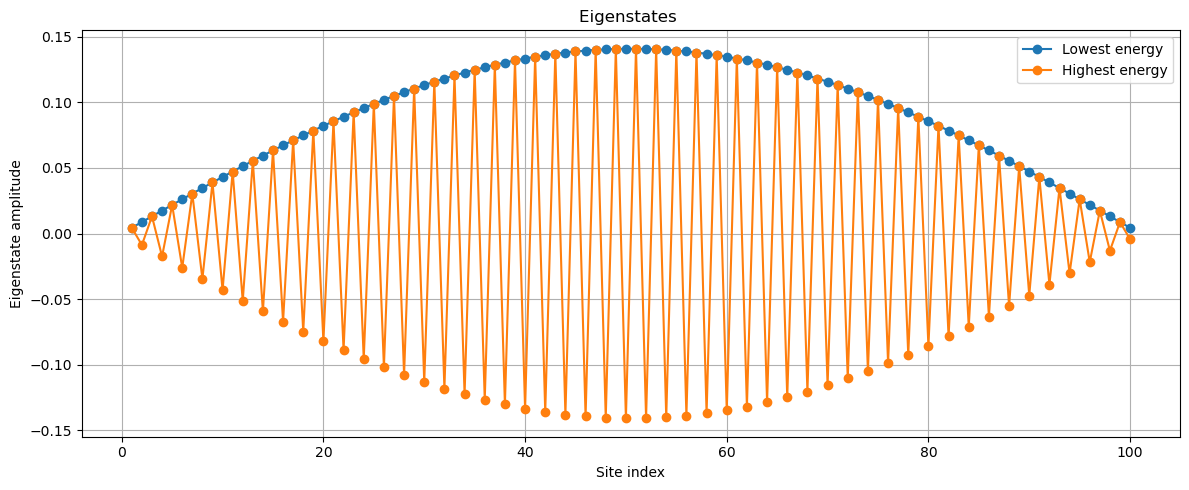

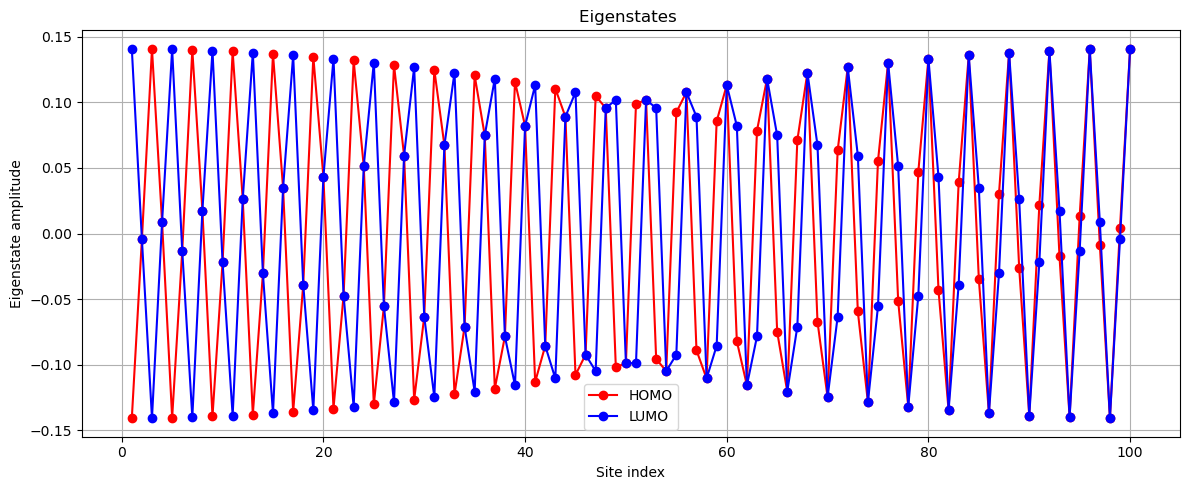

In [110]:
N = 100
#Create a nxn matrix with all diagonal values equal to -5 and super diagonal values equal to -1
H = np.diag(-5*np.ones(N)) + np.diag(-1 * np.ones(N - 1), k=-1) + np.diag(-1 * np.ones(N - 1), k=1)
print("Hamiltonian Matrix H:")
print(H)

eigval, eigvec = np.linalg.eigh(H)
Plot_eigenstates_and_energy_levels(N,eigval, eigvec, bin_width=0.4)